In [1]:
%load_ext autoreload
%autoreload 2
import sys

import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np
import lbg
sys.path.append('../')
from conversion import conv_COSMOS_XMM
import redshift_distribution_format

In [2]:
data_path = '/global/cfs/cdirs/desi/users/cpayerne/data_WP221_Target_selection/photometric_catalogs/'
catalog = Table.read(data_path + 'COSMOS_11bands-SExtractor-Lephare.fits')
mag_depth = [27,27,26.7,26.5,26] #ugriz

In [3]:
conv = conv_COSMOS_XMM

In [4]:
def refined_selection_u(tab, conv):
    
    mask  = tab[conv['u_err']] > 0
    mask *= tab[conv['g_err']] > 0
    mask *= tab[conv['r_err']] > 0

    mask *= tab[conv['r_err']] < 1

    mask *= abs(tab[conv['u']] - tab[conv['g']])  < 10
    mask *= abs(tab[conv['g']] - tab[conv['r']])  < 10

    mask *= tab[conv['r']] > 22
    
    return mask

def refined_selection_g(tab, conv):
    
    mask = tab[conv['g_err']] > 0
    mask *= tab[conv['r_err']] > 0
    mask *= tab[conv['i_err']] > 0
    mask *= tab[conv['i_err']] < 1

    mask *= abs(tab[conv['g']] - tab[conv['r']])  < 10
    mask *= abs(tab[conv['r']] - tab[conv['i']])  < 10

    mask *= tab[conv['i']] > 22

    return mask

def refined_selection_r(tab, conv):

    mask = tab[conv['r_err']] > 0
    mask *= tab[conv['i_err']] > 0
    mask *= tab[conv['z_err']] > 0
    mask *= tab[conv['z_err']] < 1

    mask *= abs(tab[conv['r']] - tab[conv['i']])  < 10
    mask *= abs(tab[conv['i']] - tab[conv['z']])  < 10

    mask *= tab[conv['z']] > 22

    return mask

In [5]:
def Christophe_highz_option1(tab, conv):
    #(u_g>0.0)   & (u_g > 1.5*(g_r-0.8) +2.0)  & (g_r>0.0) & (g_r<0.8)
    mask = (tab[conv['u']] - tab[conv['g']] > 0)
    mask *= (tab[conv['g']] - tab[conv['r']] > 0)
    mask *= (tab[conv['g']] - tab[conv['r']] <0.8)
    mask *= tab[conv['u']] - tab[conv['g']] > 1.5*(tab[conv['g']] - tab[conv['r']] - 0.8) + 2.0
    return mask

def Christophe_highz_option1(tab, conv):
    #(u_g>0.0)   & (u_g > 1.5*(g_r-0.8) +2.0)  & (g_r>0.0) & (g_r<0.8)
    mask = (tab[conv['u']] - tab[conv['g']] > 0.88)
    mask *= (tab[conv['g']] - tab[conv['r']] <1.2)
    mask *= tab[conv['u']] - tab[conv['g']] > 1.8*(tab[conv['g']] - tab[conv['r']]) + 0.68
    return mask
mask_udrop = lbg.LBG_SELECTION(catalog, conv, name='COSMOS_BXU_U_normagcut') * refined_selection_u(catalog, conv)
mask_udrop = Christophe_highz_option1(catalog, conv) * refined_selection_u(catalog, conv)
cat_lbg_udrop = catalog[mask_udrop]

In [6]:
redshift_distribution_format.save_targets(cat_lbg_udrop['ZPHOT'], cat_lbg_udrop['r'], 1.67,
                                         field = 'COSMOS',
                                         tracer = 'LBG',
                                         selection = 'udropout',
                                         add_name_selection = 'highz',
                                         info_about_the_sample = '')

Saved in: ../photom_redshift_distribution/
Filename: COSMOS_LBG_udropout_highz.npz


In [7]:
mask_gdrop = lbg.LBG_SELECTION(catalog, conv, name='COSMOS_G_noimagcut') * refined_selection_g(catalog, conv)
cat_lbg_gdrop = catalog[mask_gdrop]

In [8]:
redshift_distribution_format.save_targets(cat_lbg_gdrop['ZPHOT'], cat_lbg_gdrop['i'], 1.67,
                                         field = 'COSMOS',
                                         tracer = 'LBG',
                                         selection = 'gdropout',
                                         add_name_selection = '',
                                         info_about_the_sample = '')

Saved in: ../photom_redshift_distribution/
Filename: COSMOS_LBG_gdropout.npz


In [9]:
mask_rdrop = lbg.LBG_SELECTION(catalog, conv, name='COSMOS_R_nozmagcut') * refined_selection_r(catalog, conv)
cat_lbg_rdrop = catalog[mask_rdrop]

In [10]:
redshift_distribution_format.save_targets(cat_lbg_rdrop['ZPHOT'], cat_lbg_rdrop['z'], 1.67,
                                         field = 'COSMOS',
                                         tracer = 'LBG',
                                         selection = 'rdropout',
                                         add_name_selection = '',
                                         info_about_the_sample = '')

Saved in: ../photom_redshift_distribution/
Filename: COSMOS_LBG_rdropout.npz


# See results

In [11]:
N_zm_u = np.load(f'../photom_redshift_distribution/COSMOS_LBG_udropout.npz')
N_zm_u = np.load(f'../photom_redshift_distribution/COSMOS_LBG_udropout_highz.npz')
N_zm_g = np.load(f'../photom_redshift_distribution/COSMOS_LBG_gdropout.npz')
N_zm_r = np.load(f'../photom_redshift_distribution/COSMOS_LBG_rdropout.npz')

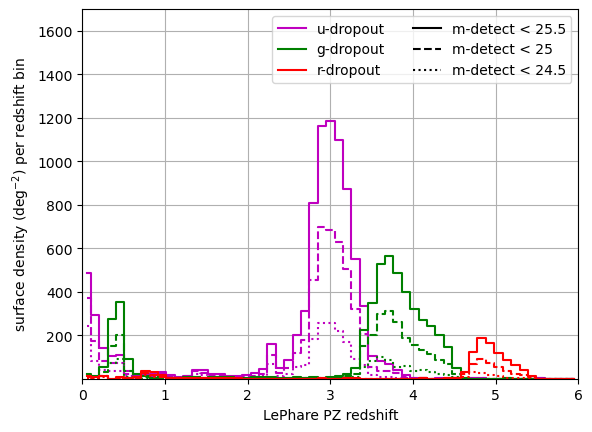

In [13]:
S = 1.67
plt.step(N_zm_u['z_center'], np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < 25.5], axis=1)/S, where='mid', color = 'm')
plt.step(N_zm_u['z_center'], np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < 25], axis=1)/S, '--',where='mid', color = 'm')
plt.step(N_zm_u['z_center'], np.sum(N_zm_u['object_count'][:,N_zm_u['mag_center'] < 24.5], axis=1)/S, ':',where='mid', color = 'm')

plt.step(N_zm_g['z_center'], np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < 25.5], axis=1)/S, '-',where='mid', color = 'g')
plt.step(N_zm_g['z_center'], np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < 25], axis=1)/S,'--', where='mid',color = 'g')
plt.step(N_zm_g['z_center'], np.sum(N_zm_g['object_count'][:,N_zm_g['mag_center'] < 24.5], axis=1)/S, ':',where='mid',color = 'g')


plt.step(N_zm_r['z_center'], np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < 25.5], axis=1)/S,'-', where='mid',color = 'r')
plt.step(N_zm_r['z_center'], np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < 25], axis=1)/S, '--',where='mid',color = 'r')
plt.step(N_zm_r['z_center'], np.sum(N_zm_r['object_count'][:,N_zm_r['mag_center'] < 24.5], axis=1)/S,':',where='mid', color = 'r')


plt.plot([], [], 'm-', label='u-dropout')


plt.plot([], [], 'g-', label='g-dropout')


plt.plot([], [], 'r-', label='r-dropout')


plt.plot([], [], '-k', label = 'm-detect < 25.5')

plt.plot([], [], '--k', label = 'm-detect < 25')

plt.plot([], [], ':k', label = 'm-detect < 24.5')
plt.ylim(0.1, 1700)
#plt.yscale('log')
plt.xlabel('LePhare PZ redshift')
plt.legend(ncols=2)
plt.ylabel('surface density (deg$^{-2}$) per redshift bin')
plt.xlim(0, 6)
plt.grid()
#plt.savefig(f'../../figures/LBG_ugr_redshift_distribution.png', dpi = 300, bbox_inches='tight' )

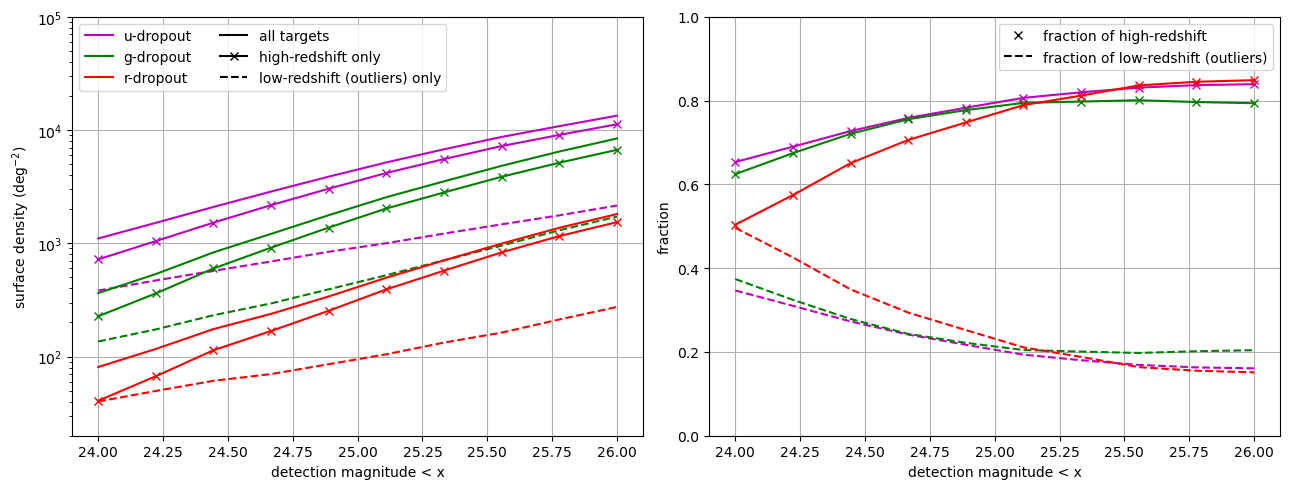

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(13,5))

rmag_vals = np.linspace(24, 26, 10)

# --- u band (z < 2 cut, z > 2 selection) ---
u_tot, u_lowz, u_highz = [], [], []
for rmag in rmag_vals:
    mask_mag = N_zm_u['mag_center'] < rmag
    mask_lowz = N_zm_u['z_center'] < 2
    mask_highz = N_zm_u['z_center'] > 2

    Ntot = np.sum(N_zm_u['object_count'][:, mask_mag])
    Nlowz = np.sum(N_zm_u['object_count'][mask_lowz][:, mask_mag])
    Nhighz = np.sum(N_zm_u['object_count'][mask_highz][:, mask_mag])

    u_tot.append(Ntot / S)
    u_lowz.append(Nlowz / S)
    u_highz.append(Nhighz / S)

# --- g band (z < 3 cut, z > 3 selection) ---
g_tot, g_lowz, g_highz = [], [], []
for rmag in rmag_vals:
    mask_mag = N_zm_g['mag_center'] < rmag
    mask_lowz = N_zm_g['z_center'] < 3
    mask_highz = N_zm_g['z_center'] > 3

    Ntot = np.sum(N_zm_g['object_count'][:, mask_mag])
    Nlowz = np.sum(N_zm_g['object_count'][mask_lowz][:, mask_mag])
    Nhighz = np.sum(N_zm_g['object_count'][mask_highz][:, mask_mag])

    g_tot.append(Ntot / S)
    g_lowz.append(Nlowz / S)
    g_highz.append(Nhighz / S)

# --- r band (z < 4 cut, z > 4 selection) ---
r_tot, r_lowz, r_highz = [], [], []
for rmag in rmag_vals:
    mask_mag = N_zm_r['mag_center'] < rmag
    mask_lowz = N_zm_r['z_center'] < 4
    mask_highz = N_zm_r['z_center'] > 4

    Ntot = np.sum(N_zm_r['object_count'][:, mask_mag])
    Nlowz = np.sum(N_zm_r['object_count'][mask_lowz][:, mask_mag])
    Nhighz = np.sum(N_zm_r['object_count'][mask_highz][:, mask_mag])

    r_tot.append(Ntot / S)
    r_lowz.append(Nlowz / S)
    r_highz.append(Nhighz / S)

# --- plotting ---

plt.subplot(121)
plt.plot(rmag_vals, u_tot, 'm-', label='u-dropout')
plt.plot(rmag_vals, u_lowz, 'm--')
plt.plot(rmag_vals, u_highz, 'mx-')

plt.plot(rmag_vals, g_tot, 'g-', label='g-dropout')
plt.plot(rmag_vals, g_lowz, 'g--')
plt.plot(rmag_vals, g_highz, 'gx-')

plt.plot(rmag_vals, r_tot, 'r-', label='r-dropout')
plt.plot(rmag_vals, r_lowz, 'r--')
plt.plot(rmag_vals, r_highz, 'rx-')

plt.plot([], [], 'k-', label='all targets')
plt.plot([], [], 'kx-', label='high-redshift only')
plt.plot([], [], 'k--', label='low-redshift (outliers) only')

plt.yscale('log')
plt.grid(which='major')

plt.ylabel('surface density (deg$^{-2}$)')
plt.xlabel(r'detection magnitude < x')
plt.legend(ncols=2, loc='upper left')
plt.ylim(20, 1e5)
plt.tight_layout()
plt.subplot(122)


# --- u dropout ---
plt.plot(rmag_vals, np.array(u_highz)/np.array(u_tot), 'mx-')
plt.plot(rmag_vals, np.array(u_lowz)/np.array(u_tot), 'm--')

# --- g dropout ---
plt.plot(rmag_vals, np.array(g_highz)/np.array(g_tot), 'gx-')
plt.plot(rmag_vals, np.array(g_lowz)/np.array(g_tot), 'g--')

# --- r dropout ---
plt.plot(rmag_vals, np.array(r_highz)/np.array(r_tot), 'rx-')
plt.plot(rmag_vals, np.array(r_lowz)/np.array(r_tot), 'r--')

plt.plot([], [], 'xk', label ='fraction of high-redshift')
plt.plot([], [], '--k', label ='fraction of low-redshift (outliers)')

plt.xlabel(r'detection magnitude < x')
plt.ylabel('fraction')
plt.ylim(0, 1)
plt.grid(which='both')
plt.legend()
plt.tight_layout()
plt.savefig(f'../../figures/LBG_ugr_densities.png', dpi = 300, bbox_inches='tight' )